# Airplane Price Dataset

## Imports

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

In [94]:
path = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/airplane_price_dataset.csv"

In [95]:
path

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/airplane_price_dataset.csv'

In [96]:
df_airplane = pd.read_csv(path + "/airplane_price_dataset.csv")

In [97]:
df_airplane.head()

,Model,Üretim Yılı,Motor Sayısı,Motor Türü,Kapasite,Menzil (km),Yakıt Tüketimi (L/saat),Saatlik Bakım Maliyeti ($),Yaş,Satış Bölgesi,Fiyat ($)
0,Bombardier CRJ200,1987,2,Turbofan,50,3000,14.36,2185.43,36,Asya,1.285708e+07
1,Bombardier CRJ200,1997,2,Turbofan,50,3000,4.03,1202.08,26,Avrupa,1.391406e+07
2,Airbus A320,1988,2,Turbofan,180,6300,13.26,761.38,35,Avustralya,9.073570e+07
3,Boeing 737,2023,2,Turbofan,162,5700,14.61,592.63,0,Avustralya,1.366597e+08
4,Cessna 172,1985,1,Piston,4,1285,18.49,4245.99,38,Güney Amerika,2.037981e+05


In [98]:
column_names = [
    'Modelo',
    'Ano de produção',
    'Número de motores',
    'Tipo de motor',
    'Capacidade',
    'Autonomia (km)',
    'Consumo de combustível (L/hora)',
    'Custo de manutenção por hora ($)',
    'Idade',
    'Região de Vendas',
    'Preço ($)'
]

In [99]:
# Renomenado as colunas
df_airplane.columns = column_names

In [100]:
df_airplane.shape

(12377, 11)

In [101]:
target = "Preço ($)"

In [102]:
df_airplane.head()

,Modelo,Ano de produção,Número de motores,Tipo de motor,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Região de Vendas,Preço ($)
0,Bombardier CRJ200,1987,2,Turbofan,50,3000,14.36,2185.43,36,Asya,1.285708e+07
1,Bombardier CRJ200,1997,2,Turbofan,50,3000,4.03,1202.08,26,Avrupa,1.391406e+07
2,Airbus A320,1988,2,Turbofan,180,6300,13.26,761.38,35,Avustralya,9.073570e+07
3,Boeing 737,2023,2,Turbofan,162,5700,14.61,592.63,0,Avustralya,1.366597e+08
4,Cessna 172,1985,1,Piston,4,1285,18.49,4245.99,38,Güney Amerika,2.037981e+05


## Analisando o Target

In [103]:
df_airplane[target]

0        1.285708e+07
1        1.391406e+07
2        9.073570e+07
3        1.366597e+08
4        2.037981e+05
             ...     
12372    3.898071e+08
12373    1.593888e+07
12374    9.870994e+07
12375    3.965207e+05
12376    2.320782e+07
Name: Preço ($), Length: 12377, dtype: float64

In [104]:
df_airplane[target].describe()

count    1.237700e+04
mean     1.988336e+08
std      2.290392e+08
min      1.458148e+05
25%      1.409681e+07
50%      8.392191e+07
75%      3.843239e+08
max      9.782132e+08
Name: Preço ($), dtype: float64

<Axes: ylabel='Frequency'>

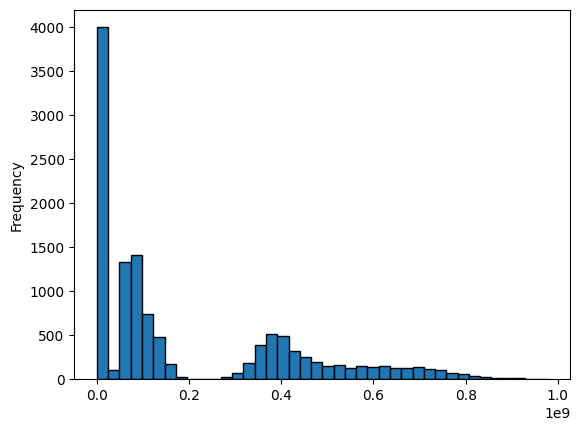

In [105]:
df_airplane[target].plot(kind="hist", bins=40, edgecolor="black")

In [106]:
# Transformando a unidade do target (de doláres para milhões de doláres)
df_airplane[target] = df_airplane[target] / 1000000

<Axes: ylabel='Frequency'>

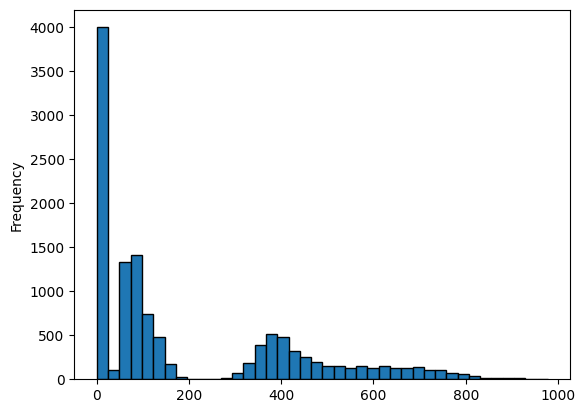

In [107]:
df_airplane[target].plot(kind="hist", bins=40, edgecolor="black")

## Separação de Dados

In [108]:
X = df_airplane.drop(target, axis=1)
y = df_airplane[target]

In [109]:
X.select_dtypes("object").describe()

,Modelo,Tipo de motor,Região de Vendas
count,12377,12377,12377
unique,6,2,6
top,Boeing 737,Turbofan,Afrika
freq,2121,10338,2171


## Preparação dos dados

In [110]:
categorical_features = ["Modelo", "Tipo de motor",	"Região de Vendas"]

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
from sklearn.preprocessing import OneHotEncoder

In [113]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[categorical_features])

X_train_categorical_columns = encoder.transform(X_train[categorical_features])
X_test_categorical_columns = encoder.transform(X_test[categorical_features])

X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_columns], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_columns], axis=1)

In [114]:
X_train.head()

,Ano de produção,Número de motores,Capacidade,Autonomia (km),Consumo de combustível (L/hora),Custo de manutenção por hora ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de Vendas_Afrika,Região de Vendas_Asya,Região de Vendas_Avrupa,Região de Vendas_Avustralya,Região de Vendas_Güney Amerika,Região de Vendas_Kuzey Amerika
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Modelagem
Testando diferentes Regressores

### Árvore de Decisão

In [115]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [121]:
y_pred = model.predict(X_test)

In [122]:
# Funcao para aplicar várias métricas de avaliação

def regression_report(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  mape = mean_absolute_percentage_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)

  return pd.Series({
      "MAE": mae,
      "MSE": mse,
      "RMSE": rmse,
      "MAPE": mape * 100,
      "R2": r2
  })

In [123]:
# Função para gerar plot dos resíduos

def plot_residuals(y_true, y_pred):
  residuals = y_true - y_pred

  plt.scatter(y_true, residuals)
  plt.axhline(y=0, color="red", linestyle="--")

  plt.xlabel("Predictions")
  plt.ylabel("Residuals")
  plt.show()

In [119]:
regression_report(y_test, y_pred)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
MAPE      11.671136
R2         0.963141
dtype: float64

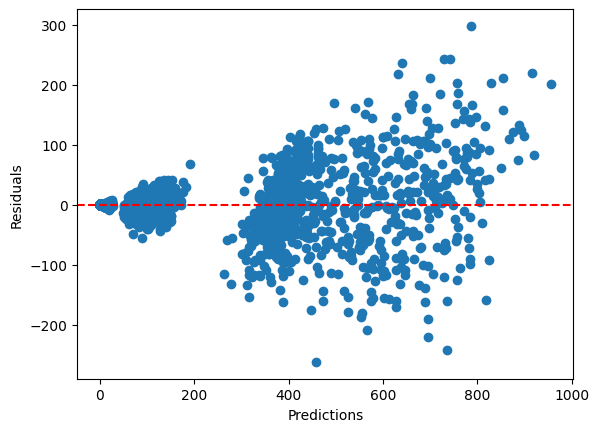

In [124]:
plot_residuals(y_test, y_pred)